# Recomendador de categorías para clientes
## Aprendizaje supervisado — clasificación multietiqueta (multi-label)

En este ejemplo queremos recomendar **categorías**, no productos específicos.

Un mismo cliente puede estar interesado simultáneamente en varias categorías, por ejemplo:

- Tecnología = 1
- Hogar = 1
- Deportes = 0
- Belleza = 0
- Alimentos = 1

Por eso el problema se formula como **clasificación multietiqueta**: cada cliente puede tener más de una etiqueta positiva.

El archivo `clientes_categorias.csv` es **sintético y educativo**.

## Objetivos de la clase

1. Diferenciar clasificación **binaria, multiclase y multietiqueta**.
2. Definir las categorías como variables objetivo aprendidas desde datos históricos.
3. Entrenar un modelo supervisado que entregue una **probabilidad por categoría**.
4. Convertir probabilidades en un **Top-N de recomendaciones**.
5. Evaluar un problema multietiqueta con F1 y Hamming Loss.
6. Interpretar qué variables influyen en una categoría.
7. Comprender por qué recomendar categorías suele ser más manejable que recomendar miles de productos.

In [1]:
# !pip install pandas numpy scikit-learn matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import f1_score, hamming_loss, accuracy_score

pd.set_option('display.max_columns', None)

## 1. Cargar los datos

Cada fila representa un cliente y contiene dos grupos de columnas:

**Características del cliente**
- edad,
- gasto,
- compras recientes,
- ticket promedio,
- visitas web,
- uso de descuentos,
- canal preferido,
- nivel de fidelidad, etc.

**Etiquetas objetivo**
- `Cat_Tecnologia`
- `Cat_Hogar`
- `Cat_Deportes`
- `Cat_Belleza`
- `Cat_Alimentos`

En un caso real, estas etiquetas podrían indicar si el cliente compró o mostró interés en esa categoría durante un **período futuro definido**, usando solamente información anterior para predecirlas.

In [2]:
df = pd.read_csv('clientes_categorias.csv')
print('Filas y columnas:', df.shape)
df.head()

Filas y columnas: (2200, 16)


,CustomerID,Age,MonthlySpend,Purchases3M,AvgTicket,WebVisits30D,DiscountUseRate,Returns6M,PreferredChannel,LoyaltyLevel,Region,Cat_Tecnologia,Cat_Hogar,Cat_Deportes,Cat_Belleza,Cat_Alimentos
0,R200000,55,96.24,7,33.11,11,0.425,0,Web,Bronce,Centro,0,1,0,0,0
1,R200001,60,59.09,4,31.45,14,0.582,0,App,Oro,Sur,0,1,0,0,0
2,R200002,28,407.18,2,217.45,5,0.222,1,Web,Plata,Norte,1,0,0,1,1
3,R200003,70,92.55,6,23.76,12,0.143,1,App,Bronce,Centro,0,0,0,1,0
4,R200004,49,96.98,6,34.02,17,0.230,1,Tienda,Bronce,Centro,0,0,0,0,1


## 2. Multiclase vs. multietiqueta

### Multiclase
Solo puede elegirse **una** clase entre varias:

```text
Cliente → Tecnología
```

### Multietiqueta
Puede haber **varias clases positivas al mismo tiempo**:

```text
Cliente → Tecnología + Hogar + Alimentos
```

Para un recomendador de categorías, la segunda opción suele ser más natural porque un cliente puede tener múltiples intereses.

In [3]:
target_columns = [
    'Cat_Tecnologia', 'Cat_Hogar', 'Cat_Deportes',
    'Cat_Belleza', 'Cat_Alimentos'
]

# ¿Cuántas categorías positivas tiene cada cliente?
df['CantidadCategorias'] = df[target_columns].sum(axis=1)

print('Cantidad de categorías positivas por cliente:')
print(df['CantidadCategorias'].value_counts().sort_index())

print('\nFrecuencia de cada categoría:')
print(df[target_columns].mean().sort_values(ascending=False).round(3))

Cantidad de categorías positivas por cliente:
CantidadCategorias
1    1443
2     535
3     184
4      31
5       7
Name: count, dtype: int64

Frecuencia de cada categoría:
Cat_Alimentos     0.449
Cat_Hogar         0.400
Cat_Belleza       0.285
Cat_Tecnologia    0.185
Cat_Deportes      0.147
dtype: float64


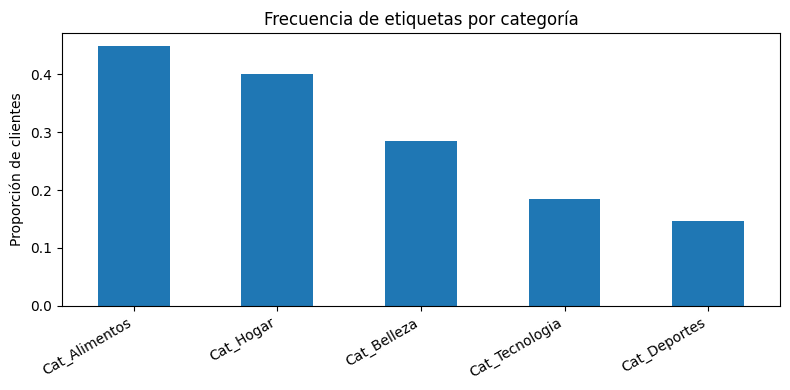

In [4]:
# Gráfico simple de prevalencia por categoría.
prevalence = df[target_columns].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
prevalence.plot(kind='bar')
plt.ylabel('Proporción de clientes')
plt.title('Frecuencia de etiquetas por categoría')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 3. Separar variables de entrada y objetivos

Una diferencia importante con churn es que ahora `y` **no es una sola columna**. Tenemos una matriz con una columna binaria por categoría.

In [5]:
feature_columns = [
    'Age', 'MonthlySpend', 'Purchases3M', 'AvgTicket',
    'WebVisits30D', 'DiscountUseRate', 'Returns6M',
    'PreferredChannel', 'LoyaltyLevel', 'Region'
]

X = df[feature_columns]
y = df[target_columns]

print('X:', X.shape)
print('y:', y.shape)
y.head()

X: (2200, 10)
y: (2200, 5)


,Cat_Tecnologia,Cat_Hogar,Cat_Deportes,Cat_Belleza,Cat_Alimentos
0,0,1,0,0,0
1,0,1,0,0,0
2,1,0,0,1,1
3,0,0,0,1,0
4,0,0,0,0,1


## 4. Train/Test

Separamos datos de entrenamiento y prueba para evaluar el modelo con clientes que no utilizó durante el aprendizaje.

Nuevamente usamos `random_state=0` para que la división sea **reproducible**.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=0
)

print('Entrenamiento:', X_train.shape, y_train.shape)
print('Prueba:', X_test.shape, y_test.shape)

Entrenamiento: (1760, 10) (1760, 5)
Prueba: (440, 10) (440, 5)


## 5. Preparación de datos + One-vs-Rest

Usaremos una estrategia sencilla:

- Preprocesamos variables numéricas y categóricas.
- Entrenamos una **regresión logística independiente para cada categoría** mediante `OneVsRestClassifier`.

Conceptualmente, el sistema aprende preguntas como:

> ¿Este cliente tiene interés en Tecnología? Sí/No  
> ¿Este cliente tiene interés en Hogar? Sí/No  
> ¿Este cliente tiene interés en Deportes? Sí/No

Como cada decisión es independiente, varias categorías pueden quedar con alta probabilidad simultáneamente.

In [7]:
numeric_features = [
    'Age', 'MonthlySpend', 'Purchases3M', 'AvgTicket',
    'WebVisits30D', 'DiscountUseRate', 'Returns6M'
]
categorical_features = ['PreferredChannel', 'LoyaltyLevel', 'Region']

preprocess = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

recommender = Pipeline([
    ('preprocess', preprocess),
    ('classifier', OneVsRestClassifier(
        LogisticRegression(max_iter=1000, random_state=0)
    ))
])

recommender.fit(X_train, y_train)
print('Recomendador entrenado correctamente.')

Recomendador entrenado correctamente.


## 6. Probabilidad por categoría

Esta es la parte clave para un recomendador.

En vez de forzar una sola categoría, obtenemos una probabilidad aproximada para cada una. Luego podemos ordenar esas probabilidades y recomendar, por ejemplo, las **Top 3 categorías**.

In [8]:
probabilities = recommender.predict_proba(X_test)

prob_df = pd.DataFrame(
    probabilities,
    columns=[c.replace('Cat_', '') for c in target_columns],
    index=X_test.index
)

prob_df.head().round(3)

,Tecnologia,Hogar,Deportes,Belleza,Alimentos
1320,0.063,0.626,0.093,0.131,0.357
1367,0.266,0.349,0.141,0.659,0.251
1291,0.390,0.193,0.249,0.432,0.527
264,0.228,0.051,0.361,0.327,0.743
728,0.332,0.166,0.298,0.478,0.337


In [9]:
def top_n_categories(prob_row, n=3):
    # Devuelve las n categorías con mayor probabilidad para un cliente.
    return prob_row.sort_values(ascending=False).head(n)

# Revisamos las recomendaciones de los primeros 5 clientes del conjunto de prueba.
for idx in prob_df.index[:5]:
    print(f'Cliente índice {idx}')
    print(top_n_categories(prob_df.loc[idx], n=3).round(3))
    print('-' * 40)

Cliente índice 1320
Hogar        0.626
Alimentos    0.357
Belleza      0.131
Name: 1320, dtype: float64
----------------------------------------
Cliente índice 1367
Belleza       0.659
Hogar         0.349
Tecnologia    0.266
Name: 1367, dtype: float64
----------------------------------------
Cliente índice 1291
Alimentos     0.527
Belleza       0.432
Tecnologia    0.390
Name: 1291, dtype: float64
----------------------------------------
Cliente índice 264
Alimentos    0.743
Deportes     0.361
Belleza      0.327
Name: 264, dtype: float64
----------------------------------------
Cliente índice 728
Belleza       0.478
Alimentos     0.337
Tecnologia    0.332
Name: 728, dtype: float64
----------------------------------------


## 7. Umbral vs. Top-N

Hay dos estrategias diferentes:

### A. Umbral
Recomendamos todas las categorías cuya probabilidad sea mayor, por ejemplo, a `0.50`.

### B. Top-N
Siempre entregamos las categorías con mayor probabilidad, por ejemplo las **3 mejores**, aunque alguna esté bajo 0.50.

Para un recomendador comercial, **Top-N** suele ser práctico cuando queremos llenar un espacio concreto de recomendaciones. Para evaluación estadística de etiquetas, normalmente usamos un **umbral**.

In [10]:
# Predicción binaria con umbral 0.50.
y_pred = (probabilities >= 0.50).astype(int)

micro_f1 = f1_score(y_test, y_pred, average='micro')
macro_f1 = f1_score(y_test, y_pred, average='macro')
h_loss = hamming_loss(y_test, y_pred)
subset_accuracy = accuracy_score(y_test, y_pred)

results = pd.Series({
    'F1_micro': micro_f1,
    'F1_macro': macro_f1,
    'Hamming_Loss': h_loss,
    'Subset_Accuracy': subset_accuracy
})

results.round(3)

F1_micro           0.426
F1_macro           0.284
Hamming_Loss       0.256
Subset_Accuracy    0.259
dtype: float64

### ¿Qué significan estas métricas?

- **F1 micro:** combina decisiones de todas las categorías y da mayor peso a las etiquetas frecuentes.
- **F1 macro:** calcula F1 por categoría y luego promedia, dando el mismo peso a cada categoría.
- **Hamming Loss:** proporción de etiquetas individuales que fueron clasificadas incorrectamente. **Más bajo es mejor**.
- **Subset Accuracy:** exige que **todas** las categorías de un cliente sean correctas al mismo tiempo. Es una métrica muy estricta.

Por eso no debemos alarmarnos si Subset Accuracy es considerablemente menor que otras métricas.

## 8. Recomendar categorías a un cliente nuevo

En producción recibiríamos características actuales de un cliente y generaríamos las probabilidades de interés.

Este ejemplo es completamente nuevo para el modelo.

In [11]:
cliente_nuevo = pd.DataFrame([{
    'Age': 31,
    'MonthlySpend': 185.0,
    'Purchases3M': 8,
    'AvgTicket': 52.0,
    'WebVisits30D': 22,
    'DiscountUseRate': 0.35,
    'Returns6M': 1,
    'PreferredChannel': 'App',
    'LoyaltyLevel': 'Oro',
    'Region': 'Centro'
}])

new_prob = recommender.predict_proba(cliente_nuevo)[0]
new_prob_series = pd.Series(
    new_prob,
    index=[c.replace('Cat_', '') for c in target_columns]
).sort_values(ascending=False)

print('Probabilidades estimadas:')
print(new_prob_series.round(3))

print('\nTop 3 recomendado:')
print(new_prob_series.head(3).round(3))

Probabilidades estimadas:
Tecnologia    0.526
Alimentos     0.506
Belleza       0.376
Hogar         0.315
Deportes      0.159
dtype: float64

Top 3 recomendado:
Tecnologia    0.526
Alimentos     0.506
Belleza       0.376
dtype: float64


## 9. Interpretar una categoría

Como usamos regresión logística, podemos revisar los coeficientes aprendidos para cada categoría.

Por ejemplo, para `Tecnologia`, los coeficientes positivos empujan la predicción hacia interés en esa categoría y los negativos en sentido contrario, manteniendo las demás variables constantes.

In [12]:
feature_names = recommender.named_steps['preprocess'].get_feature_names_out()
classifier = recommender.named_steps['classifier']

# La primera etiqueta corresponde a Cat_Tecnologia.
tech_model = classifier.estimators_[0]
tech_coefs = tech_model.coef_[0]

tech_table = pd.DataFrame({
    'Variable_transformada': feature_names,
    'Coeficiente': tech_coefs,
    'Odds_Ratio': np.exp(tech_coefs)
}).sort_values('Coeficiente', ascending=False)

print('Variables que más aumentan la señal hacia Tecnología:')
display(tech_table.head(8).round(3))

print('Variables que más la disminuyen:')
display(tech_table.tail(8).sort_values('Coeficiente').round(3))

Variables que más aumentan la señal hacia Tecnología:


,Variable_transformada,Coeficiente,Odds_Ratio
3,num__AvgTicket,0.415,1.514
11,cat__LoyaltyLevel_Oro,0.256,1.292
7,cat__PreferredChannel_App,0.170,1.186
4,num__WebVisits30D,0.148,1.160
2,num__Purchases3M,0.135,1.145
9,cat__PreferredChannel_Web,0.098,1.103
15,cat__Region_Sur,0.068,1.071
1,num__MonthlySpend,0.060,1.062


Variables que más la disminuyen:


,Variable_transformada,Coeficiente,Odds_Ratio
0,num__Age,-0.323,0.724
8,cat__PreferredChannel_Tienda,-0.270,0.764
12,cat__LoyaltyLevel_Plata,-0.190,0.827
14,cat__Region_Norte,-0.113,0.894
10,cat__LoyaltyLevel_Bronce,-0.067,0.935
6,num__Returns6M,-0.041,0.960
5,num__DiscountUseRate,0.035,1.035
13,cat__Region_Centro,0.043,1.044


## 10. ¿Por qué categorías y no productos?

Supongamos que una tienda tiene 20 categorías y 50.000 productos.

Predecir directamente 50.000 productos puede generar:

- demasiadas clases,
- productos con muy pocas observaciones,
- productos nuevos sin historia,
- modelos más difíciles de mantener,
- recomendaciones extremadamente específicas.

Una arquitectura sencilla puede ser:

```text
Cliente
   ↓
Modelo supervisado
   ↓
Probabilidades por categoría
   ↓
Top 3 categorías
   ↓
Reglas / ranking para escoger productos dentro de esas categorías
```

Así el modelo aprende una preferencia más estable y el catálogo puede cambiar sin tener que convertir cada producto en una clase independiente.

## 11. Cuidado con el leakage temporal

Para que este problema sea realmente predictivo debemos construir las variables correctamente.

Ejemplo correcto:

```text
Datos del cliente entre enero y marzo
            ↓
Predecir categorías compradas en abril
```

Ejemplo incorrecto:

```text
Usar compras de abril como variable de entrada
            ↓
Predecir compras de abril
```

En el segundo caso estamos entregando al modelo información del futuro que intenta predecir. Eso se llama **data leakage** y puede generar métricas artificialmente buenas.

# Resumen de estudio — preguntas guiadas con respuesta

### 1. ¿Este recomendador es aprendizaje supervisado?
Sí, si entrenamos con datos históricos donde conocemos qué categorías estuvieron asociadas a cada cliente.

### 2. ¿Es multiclase o multietiqueta?
En este ejemplo es **multietiqueta**, porque un cliente puede tener varias categorías positivas simultáneamente.

### 3. ¿Qué aprende One-vs-Rest?
Entrena un clasificador binario por categoría: Tecnología sí/no, Hogar sí/no, etc.

### 4. ¿Por qué usar probabilidades?
Porque permiten **ordenar categorías por relevancia** y construir un Top-N personalizado.

### 5. ¿Un Top 3 significa que las tres categorías tienen probabilidad mayor a 50%?
No necesariamente. Top-3 significa simplemente que son las tres probabilidades más altas.

### 6. ¿Qué diferencia existe entre umbral y Top-N?
El umbral decide qué etiquetas se consideran positivas; Top-N siempre selecciona una cantidad fija de categorías ordenadas por probabilidad.

### 7. ¿Por qué F1 es útil?
Porque combina Precision y Recall. Resulta especialmente útil cuando algunas etiquetas aparecen bastante más que otras.

### 8. ¿Qué significa Hamming Loss?
La proporción de decisiones de etiqueta incorrectas. **Cero sería perfecto**.

### 9. ¿Por qué recomendar categorías puede ser más estable que recomendar productos?
Porque reduce drásticamente el número de objetivos, aumenta la cantidad de ejemplos por clase y desacopla el modelo de cambios frecuentes del catálogo.

### 10. ¿Qué debemos evitar al construir las variables?
Usar información que ocurre después del momento en que queremos realizar la recomendación. Eso produciría **data leakage**.

## Para cerrar la clase

Un recomendador de categorías puede verse como una extensión natural de clasificación supervisada:

**en vez de predecir una sola etiqueta, estimamos varias probabilidades de interés.**

La parte de Machine Learning termina entregando un ranking de categorías. Después, una capa de negocio puede decidir qué productos, promociones o servicios mostrar dentro de esas categorías.